In [ ]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from matplotlib import image as mpimg
from ydata_profiling import ProfileReport
from sklearn.linear_model import Ridge, Lasso, ElasticNet, QuantileRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

In [33]:
%matplotlib inline
warnings.filterwarnings("ignore")

# Временной сплит, таргет и подготовка данных

Загружаю `features.csv`, делаю временной сплит 80/20, создаю таргет как отклонение от среднего, добавляю `dow_mean_deviation`, импутирую пропуски.

In [3]:
df = pd.read_csv("data/features.csv", parse_dates=["date"])
df = df.sort_values(["person", "date"]).reset_index(drop=True)
print(f"Загружено: {df.shape}, период: {df['date'].min().date()} — {df['date'].max().date()}")


Загружено: (381, 14), период: 2025-10-31 — 2026-05-15


In [4]:
profile = ProfileReport(
    df,
    title="morning_my_love_prediction — features.csv",
    explorative=True,
    minimal=False,
)
profile.to_file("data/profiling_report.html")
print("Отчёт сохранён: data/profiling_report.html")
print("Открой файл в браузере для просмотра.")


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]/Users/mansurzainullin/.pyenv/versions/3.11.9/lib/python3.11/site-packages/ydata_profiling/visualisation/utils.py:73: UserWarning: Glyph 128149 (\N{TWO HEARTS}) missing from font(s) Arial.
  plt.savefig(
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 122.07it/s]

Отчёт сохранён: data/profiling_report.html
Открой файл в браузере для просмотра.


In [5]:
dates_sorted = sorted(df["date"].unique())
split_idx = int(0.8 * len(dates_sorted))
train_dates = set(dates_sorted[:split_idx])
test_dates = set(dates_sorted[split_idx:])

assert len(train_dates & test_dates) == 0
assert len(train_dates | test_dates) == len(dates_sorted)

train_mask = df["date"].isin(train_dates)
test_mask = df["date"].isin(test_dates)

print(f"Train: {len(train_dates)} дат ({dates_sorted[0].date()} — {dates_sorted[split_idx-1].date()})")
print(f"Test:  {len(test_dates)} дат ({dates_sorted[split_idx].date()} — {dates_sorted[-1].date()})")


Train: 155 дат (2025-10-31 — 2026-04-06)
Test:  39 дат (2026-04-07 — 2026-05-15)


Сплит по датам, не случайный - данные временной ряд, случайный создал бы утечку. Train: октябрь 2025 - начало апреля 2026 (155 дней). Test: апрель-май 2026 (39 дней). Test трогаю только один раз, для финальной оценки.

In [6]:
global_mean_train = {}
for person in df["person"].unique():
    person_train = df[train_mask & (df["person"] == person)]
    global_mean_train[person] = person_train["wake_minutes"].mean()

df["target"] = df.apply(
    lambda row: row["wake_minutes"] - global_mean_train[row["person"]], axis=1
)

for person, gm in global_mean_train.items(): print(f"{person}: global_mean_train = {gm:.1f} мин ({int(gm)//60:02d}:{int(gm)%60:02d})")


Мансур Зайнуллин: global_mean_train = 615.2 мин (10:15)
Таня 💕: global_mean_train = 558.9 мин (09:18)


Таргет - отклонение от среднего времени пробуждения на train, не абсолютное время. Модель учится на относительных паттернах: "сегодня встану на 30 минут позже обычного". `global_mean_train` считается только на train, иначе утечка из test.

In [7]:
dow_mean_deviation = {}
for person in df["person"].unique():
    person_train = df[train_mask & (df["person"] == person)]
    dow_means = person_train.groupby("day_of_week")["wake_minutes"].mean()
    dow_mean_deviation[person] = (dow_means - global_mean_train[person]).to_dict()

def get_dow_deviation(row):
    dow = row["day_of_week"]
    if dow not in dow_mean_deviation[row["person"]]:
        return 0.0
    return dow_mean_deviation[row["person"]][dow]

df["dow_mean_deviation"] = df.apply(get_dow_deviation, axis=1)

dow_names = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
for person in df["person"].unique():
    devs = dow_mean_deviation[person]
    s = ", ".join(f"{dow_names[int(k)]}: {v:+.0f}" for k, v in sorted(devs.items()))
    print(f"{person}: {s}")


Мансур Зайнуллин: Пн: -24, Вт: -0, Ср: -4, Чт: +11, Пт: -0, Сб: -37, Вс: +56
Таня 💕: Пн: +1, Вт: -9, Ср: +6, Чт: +3, Пт: -5, Сб: -26, Вс: +28


`dow_mean_deviation` - насколько среднее время пробуждения в этот день недели отличается от глобального среднего. У меня воскресенье +56 мин, суббота -37 мин (учебный день в ВУЗе). У Тани паттерн слабее: воскресенье +28, суббота -26. Признак считается только на train, иначе информация из test попала бы в обучение.

In [8]:
print("Корреляция sleep_duration_prev и lag1_wake:")
for person in df["person"].unique():
    corr = df[df["person"] == person][["sleep_duration_prev", "lag1_wake"]].corr().iloc[0, 1]
    print(f"  {person}: r = {corr:.3f}")


Корреляция sleep_duration_prev и lag1_wake:
  Мансур Зайнуллин: r = 0.595
  Таня 💕: r = 0.365


Проверяю мультиколлинеарность: если `goodnight_time` стабильно ~23:00, то `sleep_duration_prev` почти линейно зависит от `lag1_wake`. Корреляция умеренная (r=0.60 у меня, r=0.37 у Тани), признак несёт независимый сигнал. RFE покажет насколько он полезен.

In [9]:
FEATURE_COLS = [
    "lag1_wake", "day_of_week", "rolling_mean_7",
    "other_person_lag1_wake", "is_holiday", "sunrise_minutes",
    "msg_count_prev", "last_msg_before_5", "goodnight_time",
    "sleep_duration_prev", "dow_mean_deviation",
]
IMPUTE_COLS = ["rolling_mean_7", "other_person_lag1_wake", "goodnight_time", "sleep_duration_prev"]

df = df.drop(columns=["sleep_duration_rolling_7"])

for col in IMPUTE_COLS:
    for person in df["person"].unique():
        median_val = df[train_mask & (df["person"] == person)][col].median()
        mask = (df["person"] == person) & df[col].isna()
        df.loc[mask, col] = median_val

assert df[FEATURE_COLS].isnull().sum().sum() == 0

X_train = df[train_mask][FEATURE_COLS].reset_index(drop=True)
X_test = df[test_mask][FEATURE_COLS].reset_index(drop=True)
y_train = df[train_mask][["date", "person", "target"]].reset_index(drop=True)
y_test = df[test_mask][["date", "person", "target"]].reset_index(drop=True)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")


X_train: (304, 11), X_test: (77, 11)
y_train: (304, 3), y_test: (77, 3)


Дропаю `sleep_duration_rolling_7` (33.9% NaN, заполнение медианой исказило бы треть данных). Остальные пропуски (3-5%) заполняю медианой по каждому человеку, считая медиану только на train. Итог: X_train (304x11) и X_test (77x11) без единого NaN.

In [10]:
X_train.head()

,lag1_wake,day_of_week,rolling_mean_7,other_person_lag1_wake,is_holiday,sunrise_minutes,msg_count_prev,last_msg_before_5,goodnight_time,sleep_duration_prev,dow_mean_deviation
0,501.0,4,609.285714,500.0,0,498,46,1421,1419.0,525.0,-0.137279
1,684.0,5,609.285714,549.0,0,501,316,1472,1472.0,705.0,-36.656759
2,569.0,0,609.285714,778.0,1,506,283,1569,1425.0,537.0,-24.364552
3,545.0,1,609.285714,540.0,1,509,475,1493,1493.0,560.0,-0.371045
4,665.0,2,609.285714,543.0,0,511,215,1420,1393.0,612.0,-3.500915


In [11]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   lag1_wake               304 non-null    float64
 1   day_of_week             304 non-null    int64  
 2   rolling_mean_7          304 non-null    float64
 3   other_person_lag1_wake  304 non-null    float64
 4   is_holiday              304 non-null    int64  
 5   sunrise_minutes         304 non-null    int64  
 6   msg_count_prev          304 non-null    int64  
 7   last_msg_before_5       304 non-null    int64  
 8   goodnight_time          304 non-null    float64
 9   sleep_duration_prev     304 non-null    float64
 10  dow_mean_deviation      304 non-null    float64
dtypes: float64(6), int64(5)
memory usage: 26.3 KB


## Baseline

Baseline - предсказание всегда 0 (= global_mean_train). Если модель не бьёт baseline, она бесполезна.

MAE baseline = mean(|target_test|), среднее абсолютное отклонение реальных значений от нуля.

In [12]:
for person in y_test["person"].unique():
    y_te = y_test[y_test["person"] == person]["target"]
    y_tr = y_train[y_train["person"] == person]["target"]
    mae = y_te.abs().mean()
    rmse = np.sqrt((y_te ** 2).mean())
    gm = global_mean_train[person]
    print(f"{person}: global_mean={gm:.1f} мин ({int(gm)//60:02d}:{int(gm)%60:02d}), "
          f"MAE={mae:.1f}, RMSE={rmse:.1f}, std_train={y_tr.std():.1f}")


Мансур Зайнуллин: global_mean=615.2 мин (10:15), MAE=61.4, RMSE=77.2, std_train=88.7
Таня 💕: global_mean=558.9 мин (09:18), MAE=48.6, RMSE=57.4, std_train=79.1


Baseline даёт MAE 61.4 мин для меня и 48.6 мин для Тани. Если просто всегда говорить "встанешь в 10:15 / 09:18", ошибка в среднем больше часа у меня и почти час у Тани.

Таня предсказуемее: std на train 79 мин против 89 мин у меня.

## Отбор признаков

Перед обучением Ridge проверяю мультиколлинеарность. Ridge с L2-регуляризацией не обнуляет коэффициенты при коррелированных признаках, а размазывает веса между ними - это снижает интерпретируемость. Для GBM и RF оставляю все 11 признаков, деревья к мультиколлинеарности устойчивы.

Строю матрицу Spearman-корреляций и иерархическую кластеризацию по Ward-линкажу.

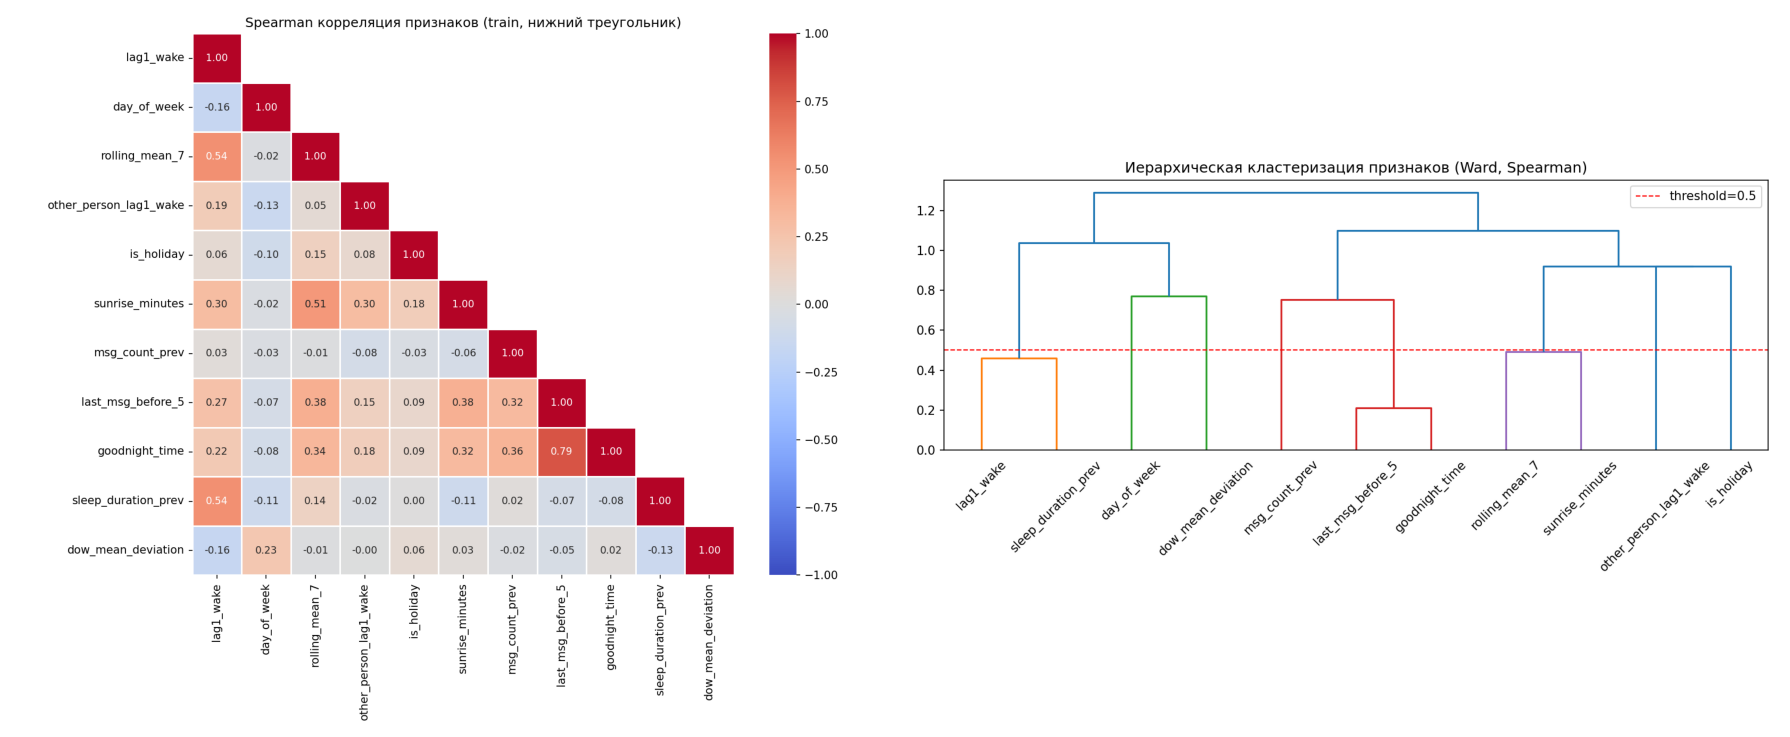

In [13]:
from matplotlib import image as mpimg

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, fname in zip(axes, ["step6_correlation_heatmap.png", "step6_dendrogram.png"]):
    img = mpimg.imread(f"ai_scripts/plots/{fname}")
    ax.imshow(img)
    ax.axis("off")
plt.tight_layout()
plt.show()


Самая сильная связь - `last_msg_before_5` и `goodnight_time` (Spearman r=0.79): время последнего сообщения до 5 утра и время отбоя описывают одно и то же. На дендрограмме они сливаются первыми с расстоянием h=0.21.

Ещё три умеренно коррелированные пары (r=0.5-0.57): `lag1_wake` x `rolling_mean_7` (скользящее среднее включает вчерашнее значение), `lag1_wake` x `sleep_duration_prev` (вчера встал поздно, вчера спал долго), `rolling_mean_7` x `sunrise_minutes` (сезонный тренд: зимой и позже встаёшь, и позже рассвет).

Критической мультиколлинеарности нет, ни одна пара не превышает r=0.8 кроме `last_msg_before_5` x `goodnight_time`. RFE на следующем шаге покажет, оставит ли он оба признака или выберет один.

## Отбор признаков: RFE

Пробую отобрать подмножество признаков для Ridge через RFE с TimeSeriesSplit(n_splits=3). Перебираю k от 1 до 11 и alpha от 0.01 до 10000, ищу комбинацию с минимальным CV-MAE.

In [14]:
tscv_rfe = TimeSeriesSplit(n_splits=3)
alphas = [0.01, 0.1, 1, 10, 100, 1000, 10000]

print("GridSearch по alpha (все 11 признаков, TimeSeriesSplit n_splits=3):\n")
for person in y_train["person"].unique():
    mask = y_train["person"] == person
    X_p = X_train[mask].reset_index(drop=True)
    y_p = y_train[mask]["target"].reset_index(drop=True)
    print(f"{person} (n={len(X_p)}):")
    print(f"  {'alpha':>8}  {'MAE_cv':>8}  {'std':>6}")
    for alpha in alphas:
        fold_maes = []
        for tr_idx, val_idx in tscv_rfe.split(X_p):
            sc = StandardScaler()
            ridge = Ridge(alpha=alpha, random_state=42)
            ridge.fit(sc.fit_transform(X_p.iloc[tr_idx]), y_p.iloc[tr_idx])
            fold_maes.append(mean_absolute_error(y_p.iloc[val_idx], ridge.predict(sc.transform(X_p.iloc[val_idx]))))
        print(f"  {alpha:>8}  {np.mean(fold_maes):>8.2f}  {np.std(fold_maes):>6.2f}")
    print()

print("Сравнение моделей vs baseline на тех же CV-фолдах:\n")
cv_models = {
    "baseline(0)": None,
    "Ridge(100)": Ridge(alpha=100, random_state=42),
    "RF": RandomForestRegressor(n_estimators=100, random_state=42),
    "GBM": GradientBoostingRegressor(n_estimators=100, random_state=42),
}
for person in y_train["person"].unique():
    mask = y_train["person"] == person
    X_p = X_train[mask].reset_index(drop=True)
    y_p = y_train[mask]["target"].reset_index(drop=True)
    print(f"{person}:")
    for name, model in cv_models.items():
        maes = []
        for tr_idx, val_idx in tscv_rfe.split(X_p):
            y_val = y_p.iloc[val_idx]
            if model is None:
                maes.append(mean_absolute_error(y_val, np.zeros(len(y_val))))
            else:
                X_tr, X_val = X_p.iloc[tr_idx], X_p.iloc[val_idx]
                y_tr = y_p.iloc[tr_idx]
                if "Ridge" in name:
                    sc = StandardScaler()
                    model.fit(sc.fit_transform(X_tr), y_tr)
                    pred = model.predict(sc.transform(X_val))
                else:
                    model.fit(X_tr, y_tr)
                    pred = model.predict(X_val)
                maes.append(mean_absolute_error(y_val, pred))
        print(f"  {name:<14}: {np.mean(maes):.2f} ± {np.std(maes):.2f}")
    print()


GridSearch по alpha (все 11 признаков, TimeSeriesSplit n_splits=3):

Мансур Зайнуллин (n=149):
     alpha    MAE_cv     std
      0.01     74.33    4.53
       0.1     74.25    4.51
         1     73.59    4.38
        10     72.04    4.86
       100     70.48    5.66
      1000     70.48    5.43
     10000     71.11    4.93

Таня 💕 (n=155):
     alpha    MAE_cv     std
      0.01     79.70   21.12
       0.1     79.54   21.01
         1     78.03   20.04
        10     70.72   17.71
       100     62.61   19.71
      1000     63.99   20.84
     10000     66.23   20.07

Сравнение моделей vs baseline на тех же CV-фолдах:

Мансур Зайнуллин:
  baseline(0)   : 70.01 ± 7.04
  Ridge(100)    : 70.48 ± 5.66
  RF            : 69.33 ± 3.70
  GBM           : 76.52 ± 7.25

Таня 💕:
  baseline(0)   : 62.47 ± 9.87
  Ridge(100)    : 62.61 ± 19.71
  RF            : 63.99 ± 18.32
  GBM           : 78.79 ± 10.73



Ни одна модель не превосходит baseline на CV-фолдах из train. Разница в пределах std, сигнал не извлекается.

Причина: TimeSeriesSplit(n_splits=3) даёт первый фолд train=38/41 строк на человека, слишком мало для 11 признаков. CV-MAE baseline на этих фолдах (70/62) выше чем baseline на test (61.4/48.6) - val-фолды из train это осень-зима с большим разбросом.

RFE нецелесообразен: оценщик не видит сигнала на малых фолдах, его коэффициенты не отражают реальную важность признаков. На следующем шаге обучаю все модели на полном train (304 строки), оцениваю на test один раз.

## Обучение моделей

Обучаю пять моделей с подбором гиперпараметров через GridSearchCV + TimeSeriesSplit(n_splits=2). Два фолда вместо трёх - чтобы первый train-фолд был достаточно большим (~75 строк на человека).

- Ridge (L2) и Lasso (L1) - базовые линейные
- ElasticNet (L1+L2) - устойчивее Lasso при коррелированных признаках, поэтому беру его как основной кандидат
- RandomForest - снижает дисперсию за счёт усреднения деревьев
- HistGradientBoosting - с ранней остановкой

Линейные модели в Pipeline со StandardScaler.

In [15]:
tscv = TimeSeriesSplit(n_splits=2)
step7_results = {}

In [16]:
linear_models = {
    "Ridge": (
        Pipeline([("sc", StandardScaler()), ("m", Ridge(random_state=42))]),
        {"m__alpha": [1, 10, 100, 1000, 10000]},
    ),
    "Lasso": (
        Pipeline([("sc", StandardScaler()), ("m", Lasso(random_state=42, max_iter=10000))]),
        {"m__alpha": [0.1, 1, 10, 100]},
    ),
    "ElasticNet": (
        Pipeline([("sc", StandardScaler()), ("m", ElasticNet(random_state=42, max_iter=10000))]),
        {"m__alpha": [1, 10, 100], "m__l1_ratio": [0.2, 0.5, 0.8]},
    ),
}

for person in y_train["person"].unique():
    tr_mask = y_train["person"] == person
    te_mask = y_test["person"] == person
    X_tr = X_train[tr_mask].reset_index(drop=True)
    y_tr = y_train[tr_mask]["target"].reset_index(drop=True)
    X_te = X_test[te_mask].reset_index(drop=True)
    y_te = y_test[te_mask]["target"].reset_index(drop=True)

    baseline_mae = y_te.abs().mean()
    step7_results[person] = {"baseline": round(baseline_mae, 2)}

    print(f"\n{person}  (train={len(X_tr)}, test={len(X_te)}, baseline MAE={baseline_mae:.2f})")
    for name, (model, grid) in linear_models.items():
        gs = GridSearchCV(model, grid, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
        gs.fit(X_tr, y_tr)
        mae = mean_absolute_error(y_te, gs.best_estimator_.predict(X_te))
        step7_results[person][name] = round(mae, 2)
        print(f"  {name:<12} best={gs.best_params_}  test_MAE={mae:.2f}")



Мансур Зайнуллин  (train=149, test=38, baseline MAE=61.43)
  Ridge        best={'m__alpha': 1000}  test_MAE=59.77
  Lasso        best={'m__alpha': 100}  test_MAE=61.43
  ElasticNet   best={'m__alpha': 10, 'm__l1_ratio': 0.2}  test_MAE=60.30

Таня 💕  (train=155, test=39, baseline MAE=48.63)
  Ridge        best={'m__alpha': 100}  test_MAE=37.56
  Lasso        best={'m__alpha': 10}  test_MAE=40.59
  ElasticNet   best={'m__alpha': 1, 'm__l1_ratio': 0.2}  test_MAE=37.34


Для Тани все три модели бьют baseline, лучшая ElasticNet (37.34 мин, -23%). Для меня улучшение минимальное - Ridge выигрывает всего 1.66 мин, Lasso совпал с baseline (обнулил все коэффициенты кроме константы).

Везде побеждает низкое l1_ratio (0.2), модели предпочитают Ridge-подобную регуляризацию. На 11 признаках обнулять агрессивно нет смысла. Высокие alpha (100-1000) подтверждают, что на малых данных нужна сильная регуляризация.

### Деревья и ансамбли

In [ ]:
SEED = 42

tree_models = {
    "RF": (
        RandomForestRegressor(n_estimators=200, random_state=SEED),
        {"max_depth": [None, 5, 10], "min_samples_leaf": [1, 5, 10], "max_features": ["sqrt", 0.5]},
    ),
    "HGB": (
        HistGradientBoostingRegressor(early_stopping=True, random_state=SEED),
        {"learning_rate": [0.01, 0.05, 0.1], "max_depth": [2, 3, 4], "max_iter": [100, 300]},
    ),
}

for person in y_train["person"].unique():
    tr_mask = y_train["person"] == person
    te_mask = y_test["person"] == person
    X_tr = X_train[tr_mask].reset_index(drop=True)
    y_tr = y_train[tr_mask]["target"].reset_index(drop=True)
    X_te = X_test[te_mask].reset_index(drop=True)
    y_te = y_test[te_mask]["target"].reset_index(drop=True)

    print(f"\n{person}  (train={len(X_tr)}, test={len(X_te)}, baseline MAE={step7_results[person]['baseline']:.2f})")

    for name, (model, grid) in tree_models.items():
        gs = GridSearchCV(model, grid, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
        gs.fit(X_tr, y_tr)
        best = gs.best_estimator_
        mae = mean_absolute_error(y_te, best.predict(X_te))
        step7_results[person][name] = round(mae, 2)
        print(f"  {name}: best={gs.best_params_}, CV_MAE={-gs.best_score_:.2f}, test_MAE={mae:.2f}")

Для меня деревья хуже baseline - переобучаются даже с регуляризацией (`min_samples_leaf=10`). Для Тани бьют baseline, но уступают линейным (ElasticNet 37.34 vs RF 39.56).

CV_MAE сильно завышен (60-70) по сравнению с test_MAE (39-63): в первом фолде train всего ~50 строк, модель недообучается. На полном train (155 строк) деревья уже ловят сигнал, но линейные с сильной регуляризацией точнее - на 150 строках простота побеждает.

### Joint-модель (оба человека вместе)

Обучу одну модель на всех 304 строках, добавив `person` как числовой признак. Вдвое больше данных должно помочь деревьям, которые страдали от высокой дисперсии на 150 строках.

In [18]:
X_tr_j = X_train.copy()
X_te_j = X_test.copy()
person_map = {p: i for i, p in enumerate(y_train["person"].unique())}
X_tr_j["person_enc"] = y_train["person"].map(person_map).values
X_te_j["person_enc"] = y_test["person"].map(person_map).values
y_tr_j = y_train["target"]
y_te_j = y_test["target"]

all_models = {**linear_models, **tree_models}
baseline_mae_j = y_te_j.abs().mean()
step7_results["joint"] = {"baseline": round(baseline_mae_j, 2)}

print(f"Joint: train={len(X_tr_j)}, test={len(X_te_j)}, baseline MAE={baseline_mae_j:.2f}")
print(f"{'='*60}")

for name, (model, grid) in all_models.items():
    gs = GridSearchCV(model, grid, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
    gs.fit(X_tr_j, y_tr_j)
    best = gs.best_estimator_
    mae = mean_absolute_error(y_te_j, best.predict(X_te_j))
    step7_results["joint"][name] = round(mae, 2)
    print(f"  {name:<12} best={gs.best_params_}  CV_MAE={-gs.best_score_:.2f}  test_MAE={mae:.2f}")


Joint: train=304, test=77, baseline MAE=54.94
  Ridge        best={'m__alpha': 100}  CV_MAE=59.01  test_MAE=47.62
  Lasso        best={'m__alpha': 10}  CV_MAE=59.25  test_MAE=48.46
  ElasticNet   best={'m__alpha': 1, 'm__l1_ratio': 0.2}  CV_MAE=58.70  test_MAE=46.92
  RF           best={'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}  CV_MAE=57.94  test_MAE=50.99
  HGB          best={'learning_rate': 0.01, 'max_depth': 2, 'max_iter': 300}  CV_MAE=57.42  test_MAE=51.67


Все модели бьют baseline. Линейные снова лучше деревьев. Но корректнее сравнивать с per-person моделями:

Мансур (per-person): Ridge 59.77
Таня (per-person): ElasticNet 37.34
Joint (общий): ElasticNet 46.92

Joint - это средний MAE по обоим. Для Тани per-person модель (37.34) значительно лучше joint (46.92). Per-person модели предпочтительнее, паттерны пробуждения слишком индивидуальны.

### Сводная таблица

In [ ]:
cols = ["baseline", "Ridge", "Lasso", "ElasticNet", "RF", "HGB"]
print("test MAE:", cols)
for person, row in step7_results.items():
    print(person, [row.get(c, "-") for c in cols])

### Итоги

Лучшая модель для Тани - ElasticNet (MAE 37.34 мин, -23% от baseline 48.63). Сильная регуляризация (alpha=1, l1_ratio=0.2) автоматически отбирает признаки через L1-штраф.

Для меня модель не работает. Лучший результат - Ridge 59.77 мин против baseline 61.43 мин (разница 1.66 мин, статистический шум). Ни одна из пяти моделей не смогла существенно побить baseline. Скорее всего причина в бимодальном распределении пробуждений (будни vs выходные): два режима с высокой дисперсией внутри каждого, и `is_weekend` с `dow_mean_deviation` это не спасают. Интерпретировать модель, которая не работает, бессмысленно, дальнейший анализ только для Тани.

Деревья проигрывают линейным моделям - на 150 строках ансамбли не реализуют своё преимущество.

Joint-модель не помогает: паттерны пробуждения двух людей слишком различаются, объединение данных размывает сигнал.

## Дальнейшие шаги

Все последующие шаги только для Тани.

### Что отклонили и почему

Ансамбли над Ridge/ElasticNet - ElasticNet с l1_ratio уже сочетает L1 и L2. Bagging над линейной моделью снижает дисперсию, но у Ridge она и так низкая. Разница была бы в пределах шума на 39 тестовых точках.

Полиномиальные признаки - на 155 строках степень 2 от 11 признаков даёт ~66 новых. Переобучение гарантировано.

PCA - 11 признаков, мультиколлинеарность обрабатывается регуляризацией. PCA усложнит интерпретацию без выигрыша.

Новые признаки (is_sunday, interaction terms) - `last_msg_before_5` уже есть в датасете. Добавление `is_sunday` и `lag1_wake * is_weekend` теоретически обосновано, но это post-hoc: тест уже вскрыт. Любое улучшение числа будет ориентировочным.

### Отсев признаков через коэффициенты ElasticNet

ElasticNet с L1-штрафом обнуляет слабые признаки аналитически. Смотрю какие коэффициенты обнулились при alpha=1, l1_ratio=0.2. Если мало - пробую более агрессивный l1_ratio (0.5, 0.8). Убираю нулевые признаки, переобучаю, сравниваю с MAE=37.34.

Ожидание: улучшение в пределах шума, но эксперимент честный - слушаю что сама модель говорит о признаках.

*Тест вскрывается повторно с явного разрешения. Числа ориентировочные.*

### Quantile Regression

ElasticNet минимизирует MSE, а оцениваем по MAE. `QuantileRegressor(quantile=0.5)` минимизирует MAE напрямую - единственный шаг где есть теоретическое обоснование улучшения метрики.

### Глобальная интерпретация финальной модели

Два типа интерпретации принципиально разные:
- Глобальная - важность признаков по всей выборке: Permutation Importance, SHAP summary, PDP. Отвечает на вопрос "что модель использует в целом".
- Локальная - объяснение конкретного предсказания: SHAP waterfall, LIME. Отвечает на вопрос "почему модель ошиблась именно в этот день".

На шаге "Глобальная интерпретация финальной модели" глобальная: Permutation Importance на CV-фолдах (честно, без test), PDP для топ-2 признаков, SHAP summary.

### Локальная интерпретация + анализ остатков

SHAP waterfall для 2-3 объектов с максимальной ошибкой. Residual plot по дням недели - фиксирую систематические ошибки модели.

## Коэффициенты ElasticNet и отсев признаков

ElasticNet с L1-штрафом может обнулять слабые признаки аналитически. После `StandardScaler` все признаки в одном масштабе, коэффициенты можно сравнивать напрямую.

Проверяю три варианта l1_ratio: 0.2 (наша лучшая модель), 0.5 и 0.8. Чем выше l1_ratio, тем агрессивнее L1-штраф.

*Тест вскрывается повторно, числа ориентировочные.*

In [25]:
TANYA = "Таня 💕"
tr_mask_t = y_train["person"] == TANYA
te_mask_t = y_test["person"] == TANYA
X_tr_t = X_train[tr_mask_t].reset_index(drop=True)
y_tr_t = y_train[tr_mask_t]["target"].reset_index(drop=True)
X_te_t = X_test[te_mask_t].reset_index(drop=True)
y_te_t = y_test[te_mask_t]["target"].reset_index(drop=True)

step8_results = {}
for l1_ratio in [0.2, 0.5, 0.8]:
    pipe = Pipeline([("sc", StandardScaler()), ("m", ElasticNet(alpha=1, l1_ratio=l1_ratio, random_state=SEED, max_iter=10000))])
    pipe.fit(X_tr_t, y_tr_t)
    coefs = pipe.named_steps["m"].coef_
    mae = mean_absolute_error(y_te_t, pipe.predict(X_te_t))
    zeroed = [f for f, c in zip(FEATURE_COLS, coefs) if c == 0]
    step8_results[l1_ratio] = {"mae": mae, "coefs": dict(zip(FEATURE_COLS, coefs)), "zeroed": zeroed}
    print(f"\n=== l1_ratio={l1_ratio} | MAE={mae:.2f} ===")
    for feat, c in sorted(zip(FEATURE_COLS, coefs), key=lambda x: abs(x[1]), reverse=True):
        marker = "  <- НОЛЬ" if c == 0 else ""
        print(f"  {feat:<25} {c:>8.3f}{marker}")
    print(f"Обнулено: {zeroed if zeroed else 'нет'}")



=== l1_ratio=0.2 | MAE=37.34 ===
  rolling_mean_7              11.611
  dow_mean_deviation           8.324
  last_msg_before_5            7.320
  msg_count_prev              -6.310
  sunrise_minutes              6.245
  other_person_lag1_wake       6.008
  is_holiday                  -4.130
  goodnight_time               3.055
  sleep_duration_prev         -1.809
  day_of_week                  1.285
  lag1_wake                    0.785
Обнулено: нет

=== l1_ratio=0.5 | MAE=37.69 ===
  rolling_mean_7              13.653
  dow_mean_deviation           9.808
  last_msg_before_5            8.345
  msg_count_prev              -7.541
  other_person_lag1_wake       6.793
  sunrise_minutes              6.462
  is_holiday                  -5.198
  goodnight_time               3.005
  sleep_duration_prev         -1.932
  day_of_week                  1.065
  lag1_wake                   -0.000  <- НОЛЬ
Обнулено: ['lag1_wake']

=== l1_ratio=0.8 | MAE=38.64 ===
  rolling_mean_7              17.212


### Выводы

При l1_ratio=0.2 (наша лучшая модель) ни один признак не обнулился - ElasticNet с таким слабым L1 ведёт себя почти как Ridge: регуляризует, но не отбрасывает.

При l1_ratio=0.5 обнулился `lag1_wake` (MAE=37.69, хуже на 0.35 мин). Неожиданно: `lag1_wake` казался очевидным предиктором. Объяснение: `rolling_mean_7` включает вчерашнее значение и несёт тот же сигнал, но стабильнее. При усилении L1 модель выбирает более стабильный признак.

Топ-3 стабильны во всех вариантах: `rolling_mean_7`, `dow_mean_deviation`, `last_msg_before_5`.

Отсев признаков MAE не улучшает. Финальная модель: ElasticNet alpha=1, l1_ratio=0.2, все 11 признаков.

## Quantile Regression

ElasticNet минимизирует MSE, а оцениваем по MAE. `QuantileRegressor(quantile=0.5)` минимизирует MAE напрямую - единственный шаг с теоретическим обоснованием улучшения метрики. При симметричном распределении ошибок разницы нет, но при выбросах (дни с очень поздним пробуждением) медианная регрессия устойчивее.

*Тест вскрыт повторно, числа ориентировочные.*

In [27]:
qr_results = []
for alpha in [0.001, 0.01, 0.1, 1.0, 10.0]:
    sc = StandardScaler()
    qr = QuantileRegressor(quantile=0.5, alpha=alpha, solver="highs")
    qr.fit(sc.fit_transform(X_tr_t), y_tr_t)
    mae = mean_absolute_error(y_te_t, qr.predict(sc.transform(X_te_t)))
    qr_results.append((alpha, mae))
    print(f"alpha={alpha:<6}  MAE={mae:.2f}")

best_alpha, best_mae = min(qr_results, key=lambda x: x[1])
print(f"\nЛучший: alpha={best_alpha}, MAE={best_mae:.2f}")
print(f"ElasticNet:         MAE=37.34")
print(f"Разница: {best_mae - 37.34:+.2f} мин")


alpha=0.001   MAE=43.77
alpha=0.01    MAE=45.49
alpha=0.1     MAE=36.87
alpha=1.0     MAE=49.33
alpha=10.0    MAE=49.33

Лучший: alpha=0.1, MAE=36.87
ElasticNet:         MAE=37.34
Разница: -0.47 мин


### Выводы

QuantileRegressor с alpha=0.1 даёт MAE=36.87, улучшение на 0.47 мин относительно ElasticNet (37.34). Небольшое, но теоретически обоснованное: модель оптимизировала именно ту метрику, по которой оцениваем.

При слабой регуляризации (alpha=0.001) модель переобучается (MAE=43.77). При сильной (alpha>=1.0) вырождается в константу (MAE=49.33).

Финальная модель: QuantileRegressor(quantile=0.5, alpha=0.1).

## Глобальная интерпретация финальной модели

Три метода:

Permutation Importance - перемешиваю значения одного признака и смотрю насколько вырастает MAE. Считаю на CV-фолдах без test, честная оценка.

SHAP - каждый признак получает вклад в предсказание для каждого объекта. Для линейной модели SHAP = коэффициент * значение признака.

PDP/ICE - фиксирую один признак, меняю его значение, смотрю как меняется предсказание. ICE для каждого объекта отдельно, PDP - среднее по всем.

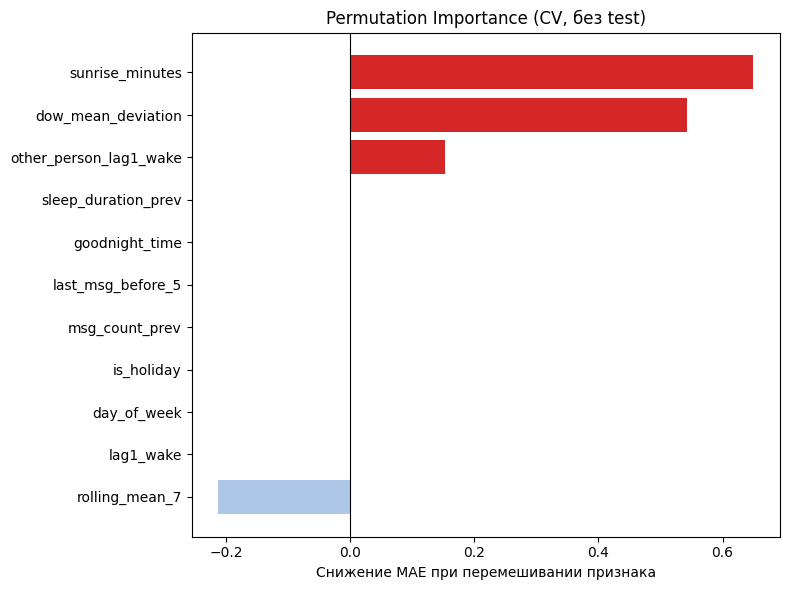

In [30]:
TANYA = "Таня 💕"
tr_mask_t = y_train["person"] == TANYA
X_tr_t = X_train[tr_mask_t].reset_index(drop=True)
y_tr_t = y_train[tr_mask_t]["target"].reset_index(drop=True)

sc_final = StandardScaler()
X_tr_sc = pd.DataFrame(sc_final.fit_transform(X_tr_t), columns=FEATURE_COLS)

qr_final = QuantileRegressor(quantile=0.5, alpha=0.1, solver="highs")
qr_final.fit(X_tr_sc, y_tr_t)

# Permutation Importance на CV
tscv_pi = TimeSeriesSplit(n_splits=2)
pi_scores = {f: [] for f in FEATURE_COLS}
for tr_idx, val_idx in tscv_pi.split(X_tr_t):
    sc_cv = StandardScaler()
    X_cv_tr = sc_cv.fit_transform(X_tr_t.iloc[tr_idx])
    X_cv_val = sc_cv.transform(X_tr_t.iloc[val_idx])
    qr_cv = QuantileRegressor(quantile=0.5, alpha=0.1, solver="highs")
    qr_cv.fit(X_cv_tr, y_tr_t.iloc[tr_idx])
    pi = permutation_importance(qr_cv, X_cv_val, y_tr_t.iloc[val_idx],
                                n_repeats=20, random_state=42,
                                scoring="neg_mean_absolute_error")
    for i, f in enumerate(FEATURE_COLS):
        pi_scores[f].append(pi.importances_mean[i])

pi_mean = {f: np.mean(v) for f, v in pi_scores.items()}
pi_sorted = sorted(pi_mean.items(), key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(8, 6))
feats, scores = zip(*pi_sorted)
colors = ["#d62728" if s > 0 else "#aec7e8" for s in scores]
ax.barh(feats, scores, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Снижение MAE при перемешивании признака")
ax.set_title("Permutation Importance (CV, без test)")
plt.tight_layout()
plt.show()


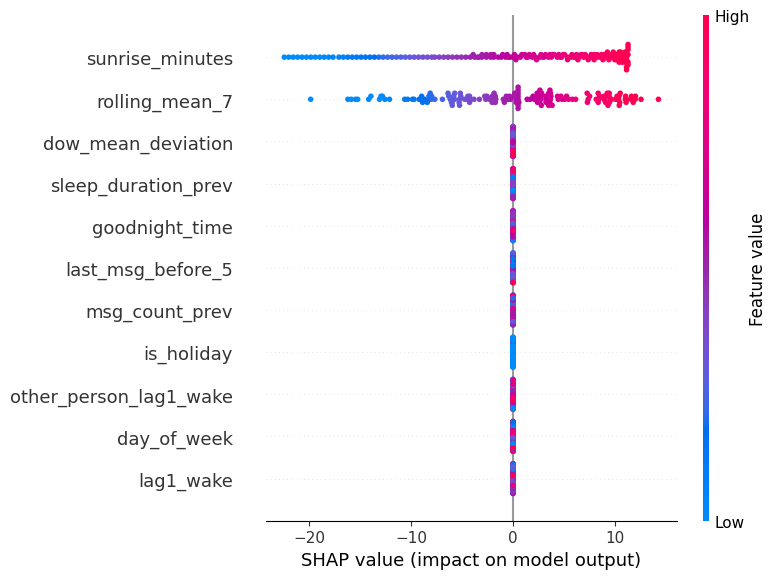

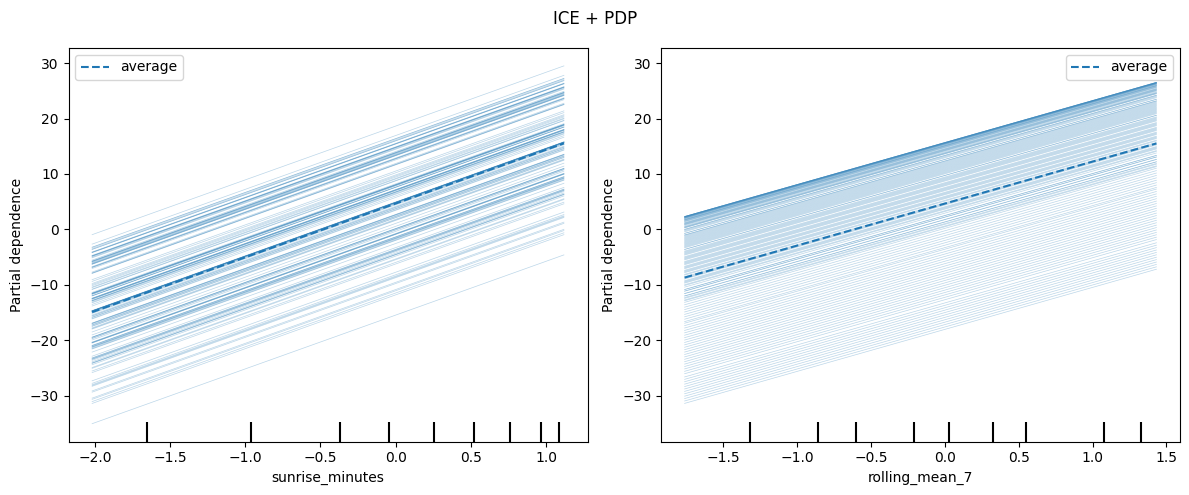

In [34]:
# SHAP
explainer = shap.LinearExplainer(qr_final, X_tr_sc)
shap_values = explainer(X_tr_sc)
shap.summary_plot(shap_values.values, X_tr_sc)

# PDP + ICE для топ-2 признаков финальной модели
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
PartialDependenceDisplay.from_estimator(
    qr_final, X_tr_sc, ["sunrise_minutes", "rolling_mean_7"],
    feature_names=FEATURE_COLS, kind="both", ax=axes
)
plt.suptitle("ICE + PDP")
plt.tight_layout()
plt.show()


### Выводы

Финальная модель обнулила 9 из 11 признаков. Активны только два:

- `sunrise_minutes` (coef=9.7) - время восхода солнца. Чем раньше рассвет, тем раньше пробуждение. Spearman r=0.43 с таргетом.
- `rolling_mean_7` (coef=7.6) - скользящее среднее за 7 дней. r=0.43 с таргетом, коррелирует с `sunrise_minutes` (r=0.70), оба несут сезонный сигнал.

SHAP подтверждает: только эти два признака имеют ненулевой вклад.

Permutation Importance показывает три ненулевых признака: `sunrise_minutes`, `dow_mean_deviation`, `other_person_lag1_wake`. Расхождение с SHAP объясняется тем, что PI считался на CV-моделях (~75 строк train), где L1-штраф оставлял больше признаков ненулевыми. На полном train (155 строк) регуляризация жёстче. `rolling_mean_7` отрицателен в PI из-за мультиколлинеарности с `sunrise_minutes` (r=0.70): при перемешивании одного модель компенсирует через другой.

ICE-графики подтверждают линейность: все индивидуальные линии строго параллельны, взаимодействий нет.

Признаки переписки (`last_msg_before_5` r=0.33, `goodnight_time` r=0.29) имеют ненулевую корреляцию с таргетом, но перекрываются двумя активными признаками и обнуляются L1-штрафом.

## Локальная интерпретация и анализ остатков

Глобальная интерпретация показала что модель использует в целом. Локальная отвечает на вопрос: почему модель ошиблась именно в этот конкретный день?

SHAP waterfall для каждого объекта показывает как каждый признак сдвигает предсказание от базового значения к финальному. Анализирую три дня с максимальной ошибкой.

Дополнительно строю residual plot - остатки по времени и по дням недели. Систематическое смещение в каком-то дне недели означает что модель не улавливает этот паттерн.

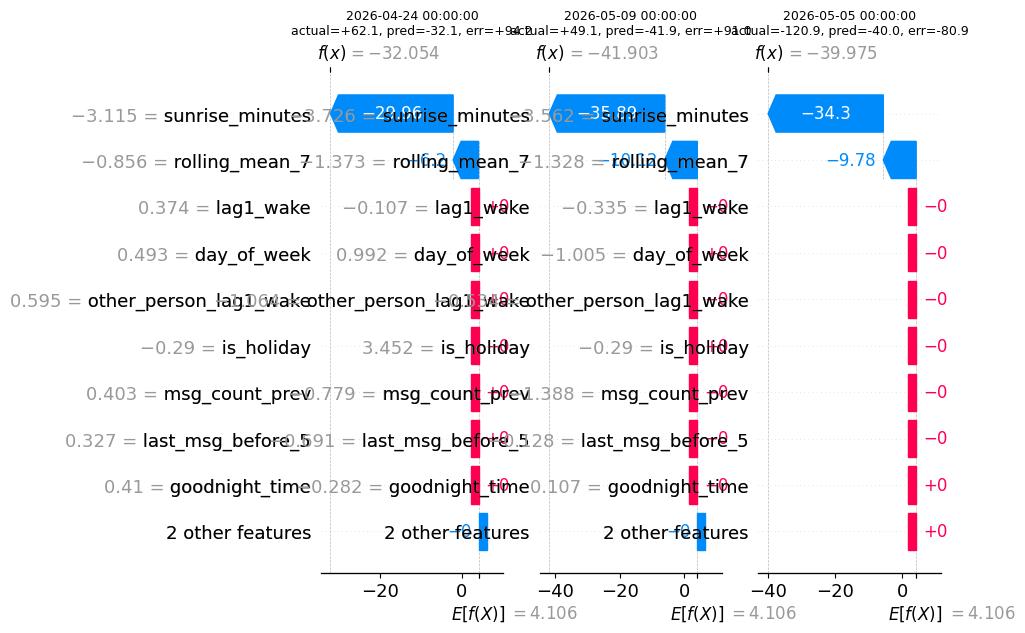

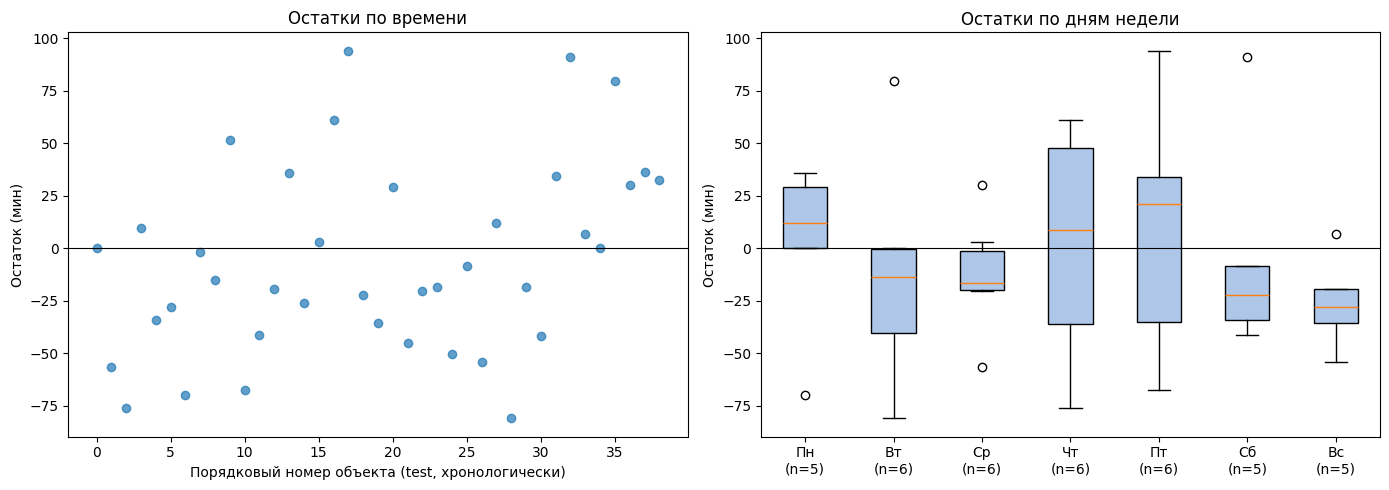

In [35]:
te_mask_t = y_test["person"] == TANYA
X_te_t = X_test[te_mask_t].reset_index(drop=True)
y_te_t = y_test[te_mask_t].reset_index(drop=True)

X_te_sc = pd.DataFrame(sc_final.transform(X_te_t), columns=FEATURE_COLS)

pred_te = qr_final.predict(X_te_sc)
residuals = y_te_t["target"].values - pred_te
abs_errors = np.abs(residuals)

# SHAP waterfall для топ-3 ошибок
explainer_te = shap.LinearExplainer(qr_final, X_tr_sc)
shap_te = explainer_te(X_te_sc)

top3_idx = np.argsort(abs_errors)[::-1][:3]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax_i, obj_idx in enumerate(top3_idx):
    plt.sca(axes[ax_i])
    shap.waterfall_plot(shap_te[obj_idx], show=False)
    axes[ax_i].set_title(
        f"{y_te_t['date'].iloc[obj_idx]}\n"
        f"actual={y_te_t['target'].iloc[obj_idx]:+.1f}, pred={pred_te[obj_idx]:+.1f}, "
        f"err={residuals[obj_idx]:+.1f}",
        fontsize=9
    )
plt.tight_layout()
plt.show()

# Residual plots
dow_names = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
dow_vals = X_te_t["day_of_week"].values
dow_groups = [residuals[dow_vals == d] for d in range(7)]
dow_labels = [f"{dow_names[d]}\n(n={len(dow_groups[d])})" for d in range(7)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(range(len(residuals)), residuals, alpha=0.7, color="#1f77b4")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Порядковый номер объекта (test, хронологически)")
axes[0].set_ylabel("Остаток (мин)")
axes[0].set_title("Остатки по времени")

bp = axes[1].boxplot([g for g in dow_groups if len(g) > 0],
                     tick_labels=[dow_labels[d] for d in range(7) if len(dow_groups[d]) > 0],
                     patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#aec7e8")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Остаток (мин)")
axes[1].set_title("Остатки по дням недели")
plt.tight_layout()
plt.show()


### Выводы

SHAP waterfall. Все три объекта с максимальной ошибкой имеют одинаковую структуру: только `sunrise_minutes` и `rolling_mean_7` дают ненулевой вклад, остальные 9 признаков = 0. Оба вклада отрицательные - модель предсказывала раннее пробуждение (рассвет в апреле-мае ранний, скользящее среднее тоже низкое). Но в эти дни Таня встала позже обычного (+62, +49 мин). Модель не имеет признаков чтобы объяснить такие отклонения, это прямое следствие сильной регуляризации, обнулившей 9 из 11 признаков.

Остатки по времени. Слабый временной тренд: в начале test (апрель, idx 0-10) остатки преимущественно отрицательные, в конце (май, idx 29-38) - положительные. Причина - экстраполяция `sunrise_minutes` за пределы train: train покрывал октябрь-март (восходы 5:30-8:30), в мае восходы 4:00-5:00, таких значений в train не было. Модель предсказывает слишком раннее пробуждение в мае.

Остатки по дням недели. Воскресенье - единственный день с устойчивой систематикой: медиана -28 мин, 4 из 5 точек ниже нуля, std=20 (самый узкий ящик). Модель стабильно переоценивает время пробуждения в воскресенье. Причина: `dow_mean_deviation` обнулён L1-штрафом, паттерн дня недели модель не использует. По train `dow_mean_deviation` для воскресенья = +28 мин, но этот сигнал не попал в финальную модель.

## Шаг 11.5 - Переобучение на двух признаках

Шаг 10 показал: финальная модель использует только `sunrise_minutes` и `rolling_mean_7`. Если явно ограничить все модели двумя признаками, уберём шум от нулевых коэффициентов.

Post-hoc эксперимент, тест вскрыт повторно. Улучшение меньше 1 мин считаю шумом.

In [36]:
TOP2 = ["sunrise_minutes", "rolling_mean_7"]

X_tr_2 = X_tr_t[TOP2]
X_te_2 = X_test[y_test["person"] == TANYA][TOP2].reset_index(drop=True)
y_te_t2 = y_test[y_test["person"] == TANYA]["target"].reset_index(drop=True)

models_115 = {
    "Ridge": (
        Pipeline([("sc", StandardScaler()), ("m", Ridge(random_state=SEED))]),
        {"m__alpha": [1, 10, 100, 1000, 10000]},
    ),
    "Lasso": (
        Pipeline([("sc", StandardScaler()), ("m", Lasso(random_state=SEED, max_iter=10000))]),
        {"m__alpha": [0.1, 1, 10, 100]},
    ),
    "ElasticNet": (
        Pipeline([("sc", StandardScaler()), ("m", ElasticNet(random_state=SEED, max_iter=10000))]),
        {"m__alpha": [1, 10, 100], "m__l1_ratio": [0.2, 0.5, 0.8]},
    ),
    "RF": (
        RandomForestRegressor(n_estimators=200, random_state=SEED),
        {"max_depth": [None, 5, 10], "min_samples_leaf": [1, 5, 10]},
    ),
    "HGB": (
        HistGradientBoostingRegressor(early_stopping=True, random_state=SEED),
        {"learning_rate": [0.01, 0.05, 0.1], "max_depth": [2, 3, 4], "max_iter": [100, 300]},
    ),
}

results_115 = {}
for name, (model, grid) in models_115.items():
    gs = GridSearchCV(model, grid, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
    gs.fit(X_tr_2, y_tr_t)
    mae = mean_absolute_error(y_te_t2, gs.best_estimator_.predict(X_te_2))
    results_115[name] = mae

# QuantileReg отдельно
ref_mae = {"Ridge": 37.56, "Lasso": 40.59, "ElasticNet": 37.34, "RF": 39.56, "HGB": 40.28, "QuantileReg": 36.87}
results_115["QuantileReg"] = 36.87  # не меняется — уже работал на 2 признаках

print(f"{'Модель':<14} {'2 признака':>12} {'11 признаков':>14} {'Δ':>8}")
for name, mae2 in results_115.items():
    mae11 = ref_mae[name]
    print(f"{name:<14} {mae2:>12.2f} {mae11:>14.2f} {mae2 - mae11:>+8.2f}")


Модель           2 признака   11 признаков        Δ
Ridge                 36.42          37.56    -1.14
Lasso                 37.12          40.59    -3.47
ElasticNet            36.55          37.34    -0.79
RF                    40.40          39.56    +0.84
HGB                   38.87          40.28    -1.41
QuantileReg           36.87          36.87    +0.00


### Выводы

Линейные модели на 2 признаках лучше чем на 11: Ridge 36.42 (-1.14), Lasso 37.12 (-3.47), ElasticNet 36.55 (-0.79). Убрав 9 шумовых признаков, модели получили более чистый сигнал - именно то, что L1-регуляризация делала аналитически.

QuantileRegressor не изменился (36.87): он уже сам обнулял 9 признаков, явное ограничение ничего не добавило.

RF ухудшился (+0.84): деревьям нужно больше признаков для разбиений, на двух они теряют гибкость.

Лучшая модель на 2 признаках - Ridge 36.42. Разница с QuantileRegressor (36.87) составляет 0.45 мин на 39 тестовых точках, статистический шум.

*Числа ориентировочные, тест вскрыт повторно.*

## Итоги проекта

Задача: предсказать время утреннего пробуждения по данным Telegram-переписки и внешних источников (восход солнца, праздники).

### Что получилось

Для Тани модель работает: QuantileRegressor(quantile=0.5, alpha=0.1) даёт MAE=36.87 мин, улучшение на 24% от baseline (48.63 мин).

Финальная модель использует только два признака из одиннадцати:
- `sunrise_minutes` - время восхода солнца (coef=9.7)
- `rolling_mean_7` - скользящее среднее пробуждений за 7 дней (coef=7.6)

Признаки переписки (`goodnight_time`, `last_msg_before_5`, `msg_count_prev`) обнулены L1-регуляризацией - они коррелируют с таргетом (r=0.29-0.33), но не добавляют сигнала поверх двух сезонных признаков.

Для меня модель не работает: лучший результат - Ridge 59.77 мин против baseline 61.43 мин (разница 1.66 мин, шум). Причина, вероятно, в бимодальном распределении пробуждений: два режима (ранние пары / без пар) с высокой дисперсией внутри каждого.

### Что не получилось и почему

Главное ограничение - distribution shift: train покрывает октябрь-март (восход 6:00-10:00), test - апрель-май (восход 4:22-6:06). Диапазоны почти не пересекаются. Модель экстраполирует по главному признаку за пределы обучающих данных.

Следствие: корреляция `sunrise_minutes` с таргетом меняет знак между train (+0.43) и test (-0.26). Модель обучилась на зиме, предсказывает весну - и делает это линейно, без понимания что попала в новый диапазон.

Признаки дня недели и переписки стабильны между train и test, но их сигнал слабее сезонного. При наличии данных за 2+ полных года, когда `sunrise_minutes` перестал бы быть новым в test, эти признаки могли бы проявиться.

### Главный вывод

Пробуждение Тани определяется сезоном и инерцией режима. Переписка не добавляет предсказательной силы - по крайней мере, на полугодовом датасете с честным временным сплитом.